In [2]:
import numpy as np
import pandas as pd
import category_encoders as ce
import matplotlib.pyplot as plt 
import seaborn as sb 

In [43]:
fp = r"C:\Users\balaj\OneDrive\Desktop\disease prediction models\raw_data\diabetes.csv".replace('\\','/')
df = pd.read_csv(fp)

In [44]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [45]:
df.shape

(768, 9)

In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [47]:
df.isna().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [48]:
(df.isna().sum()).sum()

np.int64(0)

In [49]:
df.value_counts()

Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin  BMI   DiabetesPedigreeFunction  Age  Outcome
12           140      82             43             325      39.2  0.528                     58   1          1
             121      78             17             0        26.5  0.259                     62   0          1
             106      80             0              0        23.6  0.137                     44   0          1
             100      84             33             105      30.0  0.488                     46   0          1
             92       62             7              258      27.6  0.926                     44   1          1
                                                                                                            ..
0            78       88             29             40       36.9  0.434                     21   0          1
             74       52             10             36       27.8  0.269                     22   0          1
      

In [50]:
df.nunique()

Pregnancies                  17
Glucose                     136
BloodPressure                47
SkinThickness                51
Insulin                     186
BMI                         248
DiabetesPedigreeFunction    517
Age                          52
Outcome                       2
dtype: int64

([0, 1, 2, 3, 4, 5, 6, 7, 8],
 [Text(0, 0, 'Pregnancies'),
  Text(1, 0, 'Glucose'),
  Text(2, 0, 'BloodPressure'),
  Text(3, 0, 'SkinThickness'),
  Text(4, 0, 'Insulin'),
  Text(5, 0, 'BMI'),
  Text(6, 0, 'DiabetesPedigreeFunction'),
  Text(7, 0, 'Age'),
  Text(8, 0, 'Outcome')])

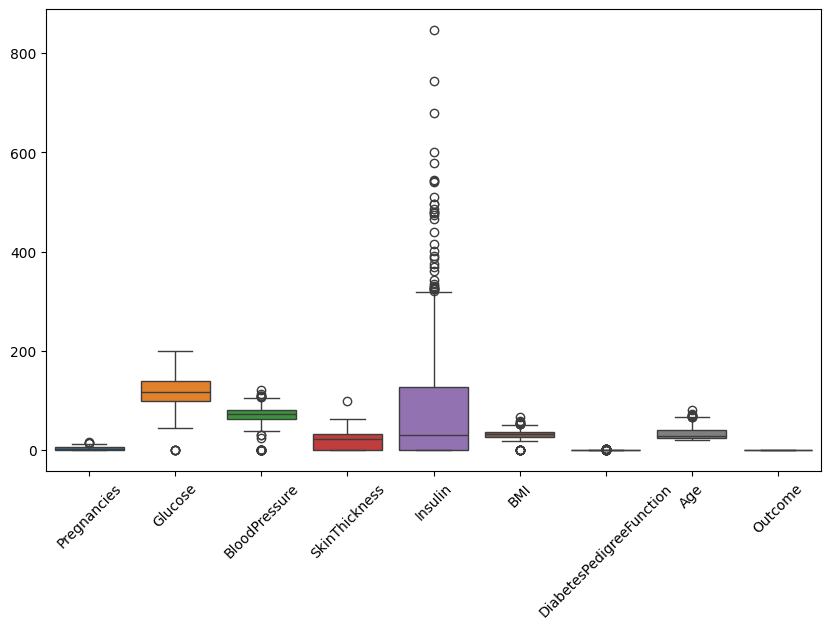

In [51]:
plt.figure(figsize=(10,6))
sb.boxplot(df)
plt.xticks(rotation=45)

In [52]:
# outlier count
ans = []
for col in df.select_dtypes(include=["int64", "float64"]):
    size = df.shape[0]
    q1 = df[col].quantile(.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    # print(f"Total outliers of {col}: {len(outliers)}")
    # print(f"Percentage of Outliers (out of {size}): {round((len(outliers)/size)*100, 2)}%")
    # print()
    ans.append({"Column": col, "Outlier Count": len(outliers), "Percentage (%)": round((len(outliers)/size)*100, 2)})

In [53]:
pd.DataFrame(ans)

,Column,Outlier Count,Percentage (%)
0,Pregnancies,4,0.52
1,Glucose,5,0.65
2,BloodPressure,45,5.86
3,SkinThickness,1,0.13
4,Insulin,34,4.43
5,BMI,19,2.47
6,DiabetesPedigreeFunction,29,3.78
7,Age,9,1.17
8,Outcome,0,0.00


In [54]:
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns

bounds = {}
for col in numeric_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    bounds[col] = (lower, upper)

mask = pd.Series(True, index=df.index)
for col, (lower, upper) in bounds.items():
    mask &= (df[col] >= lower) & (df[col] <= upper)

df_clean = df[mask].copy()
df_clean

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
5,5,116,74,0,0,25.6,0.201,30,0
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


([0, 1, 2, 3, 4, 5, 6, 7, 8],
 [Text(0, 0, 'Pregnancies'),
  Text(1, 0, 'Glucose'),
  Text(2, 0, 'BloodPressure'),
  Text(3, 0, 'SkinThickness'),
  Text(4, 0, 'Insulin'),
  Text(5, 0, 'BMI'),
  Text(6, 0, 'DiabetesPedigreeFunction'),
  Text(7, 0, 'Age'),
  Text(8, 0, 'Outcome')])

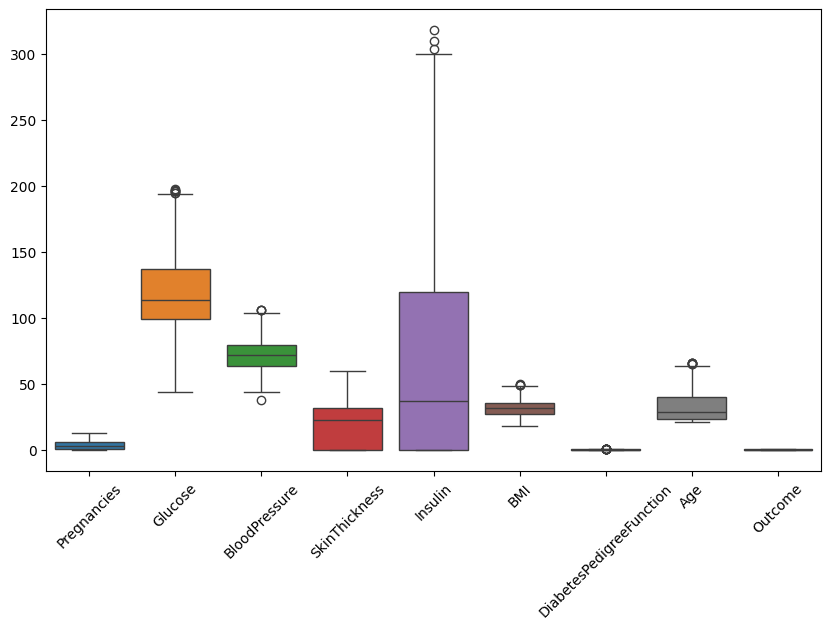

In [57]:
plt.figure(figsize=(10,6))
sb.boxplot(df_clean)
plt.xticks(rotation=45)

In [56]:
df.shape

(768, 9)

In [58]:
df_clean.to_csv('C:/Users/balaj/OneDrive/Desktop/disease prediction models/good dataset/diabetes.csv', index=False)